# Data visualization with Matplotlib

> **Explain it like I am five:** Data is a story made of numbers. A chart draws pictures of that story so our eyes can notice changes, differences, clusters, and unusual points.

Matplotlib is Python's foundational plotting library. This notebook preserves every original line, subplot, bar, histogram, scatter, pie, and sales example while adding the object-oriented approach, chart choice, labels, dates, accessibility, and saving.

## Learning goals

- understand figures and axes;
- create and customize common chart types;
- build multiple subplots;
- visualize the local sales dataset correctly;
- label, annotate, save, and close figures.


## 0. Setup

Install once only if needed:

```python
%pip install matplotlib pandas
```

The original notebook used `!pip install matplotlib`. Setup commands should not run every time the notebook runs.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Matplotlib version:", plt.matplotlib.__version__)


Matplotlib version: 3.11.0


In [2]:
from pathlib import Path

def data_path(filename):
    """Find a course data file whether Jupyter starts in the repo or lesson folder."""
    current = Path.cwd().resolve()
    lesson_parts = ("Complete-Python-Bootcamp-main", "10-Data Analysis With Python")
    candidates = [current / filename, current.joinpath(*lesson_parts, filename)]
    for parent in current.parents:
        candidates.extend([parent / filename, parent.joinpath(*lesson_parts, filename)])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r}. Start Jupyter inside this repository.")


## 1. Figure and axes

Think of a **Figure** as a sheet of paper and an **Axes** as one chart area drawn on that paper. Despite its name, one `Axes` object normally contains both the x- and y-axis.

Two styles exist:

- quick stateful style: `plt.plot(...)`;
- explicit object-oriented style: `fig, ax = plt.subplots(); ax.plot(...)`.

The object-oriented style is easier to control in larger notebooks.


## 2. Basic line plot

A line chart connects ordered observations. Use it for time or another naturally ordered variable.


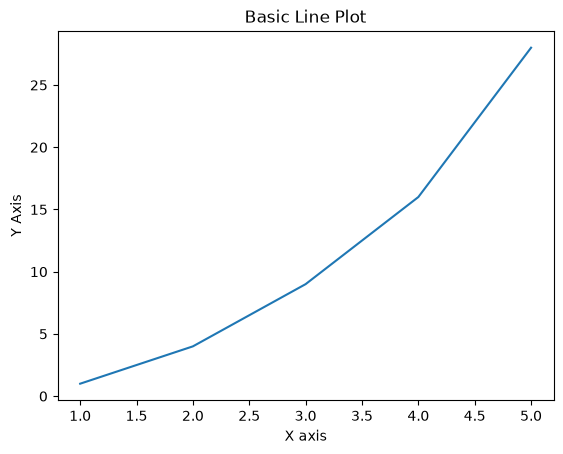

In [4]:
import matplotlib.pyplot as plt
x=[1,2,3,4,5]
y=[1,4,9,16,28]

## create a line plot
plt.plot(x,y)
plt.xlabel('X axis')
plt.ylabel('Y Axis')
plt.title("Basic Line Plot")
plt.show()


Labels should tell the reader what a value means and include units when relevant. “Day” and “Revenue (₹)” are more informative than “X axis” and “Y axis.”


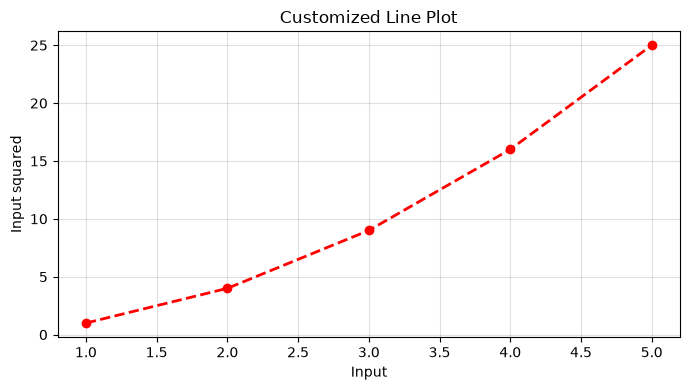

In [12]:
x=[1,2,3,4,5]
y=[1,4,9,16,25]

## create a customized line plot
plt.figure(figsize=(7, 4))
plt.plot(x,y,color='red',linestyle='--',marker='o',linewidth=2,markersize=6,)
plt.xlabel('Input')
plt.ylabel('Input squared')
plt.title('Customized Line Plot')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Object-oriented plotting

`fig` controls the whole canvas; `ax` controls one plot. `tight_layout` reduces clipped labels.


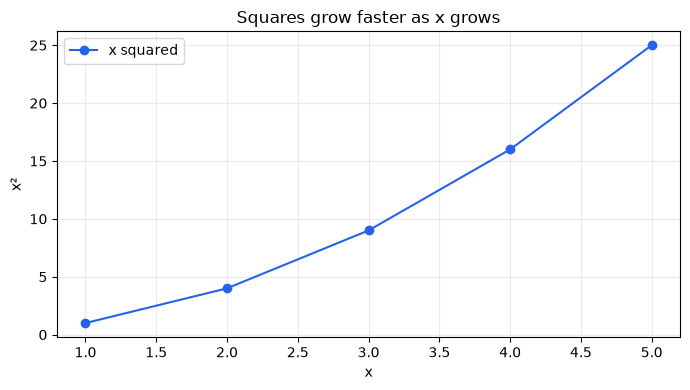

In [ ]:
# Create a figure and one plotting area (axes)
# figsize=(7, 4) means the graph will be 7 inches wide and 4 inches tall
# fig = the whole image/canvas
# ax = the actual graph area inside that image
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o', color='#2563EB', label='x squared')

# Set the graph title and the names of the x-axis and y-axis
ax.set(
    title='Squares grow faster as x grows',
    xlabel='x',
    ylabel='x²'
)

# Show the legend
# It displays the label we gave above: 'x squared'
ax.legend()

# alpha=0.25 makes the grid light/transparent
ax.grid(alpha=0.25)

# Automatically fix spacing so labels and titles do not overlap
fig.tight_layout()

# Display the final graph
plt.show()

## 4. Multiple subplots

The original example creates a 2×2 grid. Calling `plt.subplot(rows, columns, position)` activates one position. The modern `plt.subplots` form returns an array of axes and is easier to loop over.


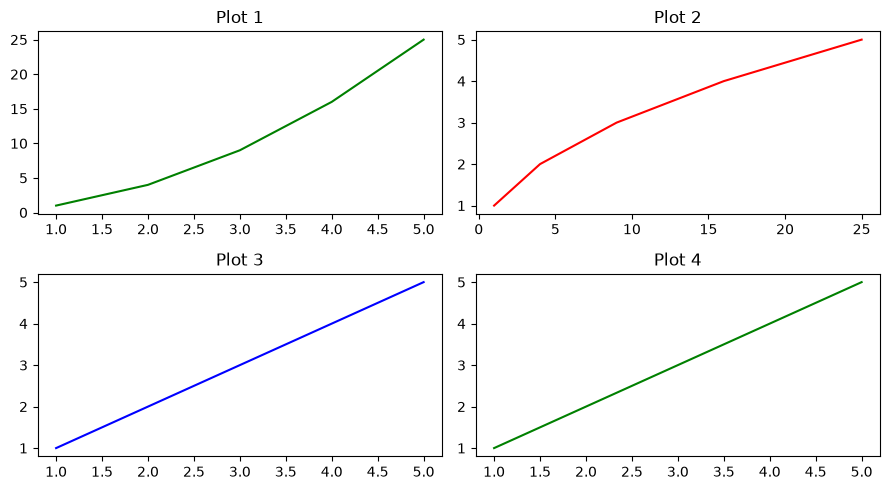

In [ ]:
## Multiple Plots
## Sample data
x = [1, 2, 3, 4, 5]
y1 = [1, 4, 9, 16, 25]
y2 = [1, 2, 3, 4, 5]

plt.figure(figsize=(9,5))

# 2,2 means:
# 2 rows and 2 columns

plt.subplot(2,2,1) # 1 means use the 1st position
plt.plot(x,y1,color='green')
plt.title("Plot 1")

plt.subplot(2,2,2)
plt.plot(y1,x,color='red')
plt.title("Plot 2")

plt.subplot(2,2,3)
plt.plot(x,y2,color='blue')
plt.title("Plot 3")

plt.subplot(2,2,4)
plt.plot(x,y2,color='green')
plt.title("Plot 4")

plt.tight_layout()
plt.show()


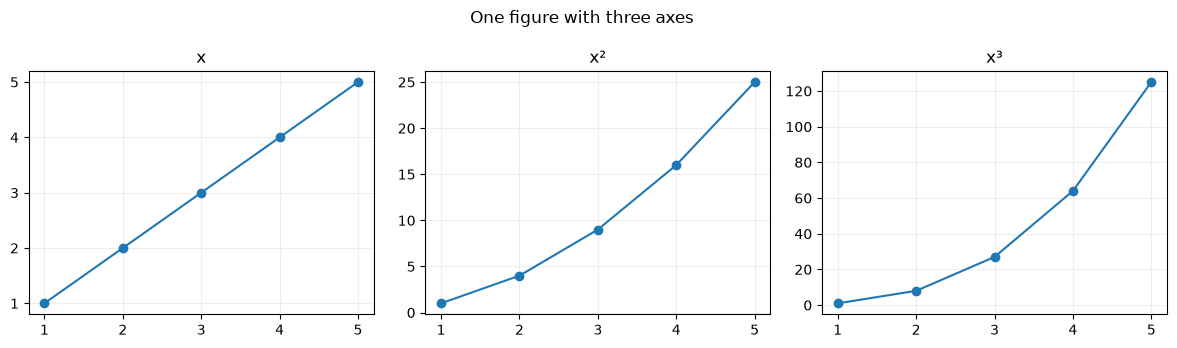

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
powers = [(1, 'x'), (2, 'x²'), (3, 'x³')]

x_values = np.arange(1, 6)
for ax, (power, label) in zip(axes, powers):
    ax.plot(x_values, x_values ** power, marker='o')
    ax.set_title(label)
    ax.grid(alpha=0.2)

fig.suptitle('One figure with three axes')
fig.tight_layout()
plt.show()


Think of this as making **one big paper with 3 small graphs on it**.

```python
# Make 1 big figure with 3 graph boxes in one row
# fig = the whole page/canvas
# axes = the 3 graph boxes inside the page
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))


# Store what power we want to use
# (1, 'x')   means x¹
# (2, 'x²')  means x²
# (3, 'x³')  means x³
powers = [(1, 'x'), (2, 'x²'), (3, 'x³')]


# Create numbers from 1 to 5
# x_values becomes: [1, 2, 3, 4, 5]
x_values = np.arange(1, 6)


# Go through each graph box and each power together
for ax, (power, label) in zip(axes, powers):

    # Draw the graph
    # x_values ** power means:
    # x¹, x², or x³
    # marker='o' adds circles on points
    ax.plot(x_values, x_values ** power, marker='o')

    # Give each small graph its own title
    ax.set_title(label)

    # Add light grid lines
    ax.grid(alpha=0.2)


# Add one big title for the whole figure
fig.suptitle('One figure with three axes')


# Fix spacing so graphs and titles do not overlap
fig.tight_layout()


# Show everything
plt.show()
```

### First understand this line

```python
fig, axes = plt.subplots(1, 3)
```

It means:

> Make **1 row** and **3 graph boxes**.

Like this:

```text
              fig = whole page

+-------------+-------------+-------------+
|             |             |             |
|   axes[0]   |   axes[1]   |   axes[2]   |
|             |             |             |
|    x        |     x²      |     x³      |
+-------------+-------------+-------------+
```

So:

* `fig` = whole paper
* `axes` = collection of the 3 graphs
* `axes[0]` = first graph
* `axes[1]` = second graph
* `axes[2]` = third graph

---

### What is `powers`?

```python
powers = [(1, 'x'), (2, 'x²'), (3, 'x³')]
```

This is just storing:

```text
1 → x
2 → x²
3 → x³
```

Each item has **two things**:

```python
(1, 'x')
```

means:

```text
power = 1
label = 'x'
```

---

### What does this make?

```python
x_values = np.arange(1, 6)
```

It creates:

```python
[1, 2, 3, 4, 5]
```

Important: `6` is **not included**.

---

### The hardest-looking line

```python
for ax, (power, label) in zip(axes, powers):
```

It is actually simple.

`zip()` joins the graphs with the powers:

```text
First graph  +  (1, 'x')
Second graph +  (2, 'x²')
Third graph  +  (3, 'x³')
```

So the loop runs **3 times**.

#### First time

```text
ax = first graph
power = 1
label = x
```

It draws:

```python
x_values ** 1
```

which gives:

```text
1, 2, 3, 4, 5
```

#### Second time

```text
ax = second graph
power = 2
label = x²
```

It draws:

```python
x_values ** 2
```

which gives:

```text
1, 4, 9, 16, 25
```

#### Third time

```text
ax = third graph
power = 3
label = x³
```

which gives:

```text
1, 8, 27, 64, 125
```

### In one sentence

This code says:

> **Create 3 graph boxes, then automatically draw x, x², and x³ in those 3 boxes.**


## 5. Bar chart: compare categories

Bar length should start from a meaningful baseline, usually zero, so differences are not exaggerated.


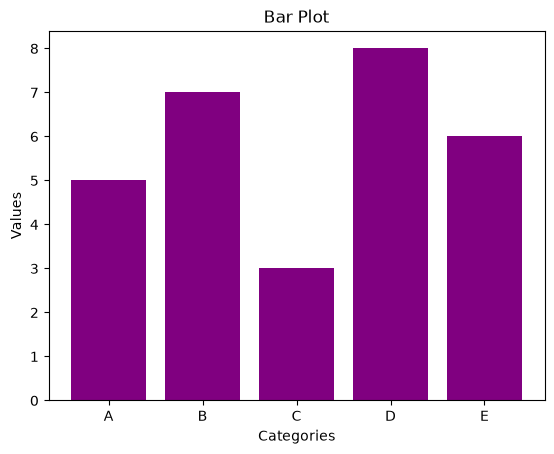

In [8]:
### Bar Plot
categories=['A','B','C','D','E']
values=[5,7,3,8,6]

## create a bar plot
plt.bar(categories,values,color='purple')
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Plot')
plt.show()


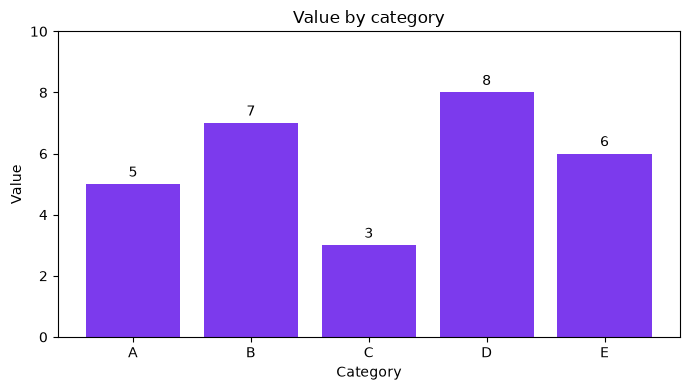

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categories, values, color='#7C3AED')
ax.bar_label(bars, padding=3)
ax.set(title='Value by category', xlabel='Category', ylabel='Value', ylim=(0, 10))
fig.tight_layout()
plt.show()


## 6. Histogram: see a distribution

A histogram puts numeric values into bins and counts how many land in each bin. Different bin widths can change the visual story, so test a reasonable choice.


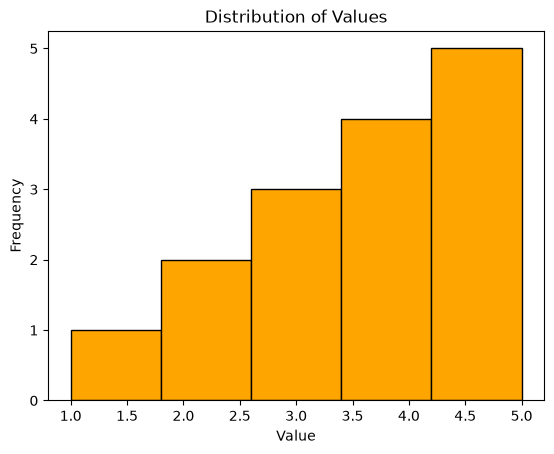

In [ ]:
# Sample data
data = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5]

## create a histogram
plt.hist(data,bins=5,color='orange',edgecolor='black') #a bin is simply a group/range of values.
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Values')
plt.show()


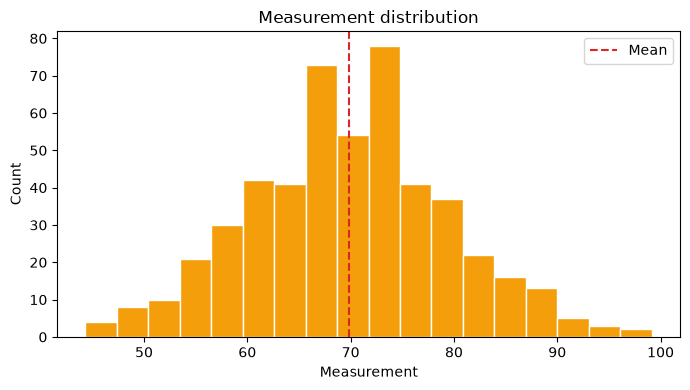

In [11]:
rng = np.random.default_rng(42)
measurements = rng.normal(loc=70, scale=10, size=500)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(measurements, bins='auto', color='#F59E0B', edgecolor='white')
ax.axvline(measurements.mean(), color='#DC2626', linestyle='--', label='Mean')
ax.set(title='Measurement distribution', xlabel='Measurement', ylabel='Count')
ax.legend()
fig.tight_layout()
plt.show()


## 7. Scatter plot: relationship between two numeric variables

One dot represents one observation. A pattern may suggest association, but it does not prove that one variable causes the other.


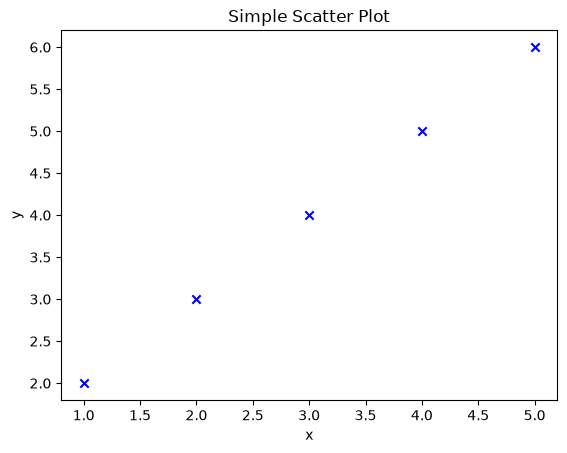

In [12]:
## create a scatter plot
# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 3, 4, 5, 6]

plt.scatter(x,y,color="blue",marker='x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Scatter Plot')
plt.show()


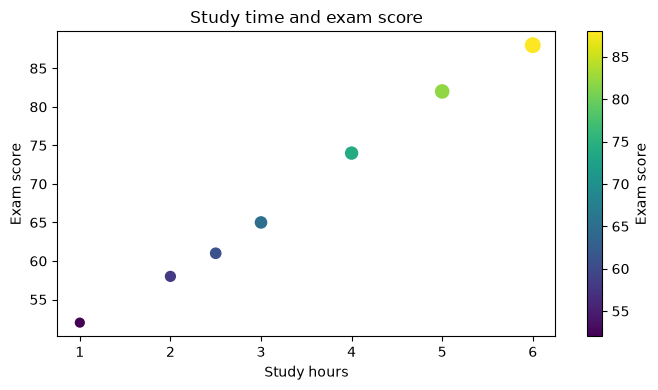

In [ ]:
study_hours = np.array([1, 2, 2.5, 3, 4, 5, 6])
exam_scores = np.array([52, 58, 61, 65, 74, 82, 88])
sizes = np.array([40, 50, 55, 65, 75, 90, 110])

# Create the figure and graph area
fig, ax = plt.subplots(figsize=(7, 4))

# Create scatter plot
# x-axis = study hours
# y-axis = exam scores
# s = size of dots
# c = color dots based on exam score
# cmap = color style used for the dots
scatter = ax.scatter(
    study_hours,
    exam_scores,
    s=sizes,
    c=exam_scores,
    cmap='viridis'
)

# Add title and axis names
ax.set(
    title='Study time and exam score',
    xlabel='Study hours',
    ylabel='Exam score'
)

# Add a color bar to explain what the dot colors mean
fig.colorbar(scatter, ax=ax, label='Exam score')

# Fix spacing
fig.tight_layout()

# Show the graph
plt.show()

## 8. Pie chart: part-to-whole with few categories

Pie charts are difficult to compare when slices are similar or numerous. Prefer a bar chart for precise comparison. The original four-slice example is reasonable for learning the API.


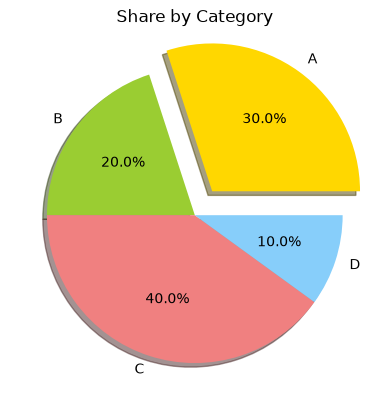

In [19]:
### pie chart

labels=['A','B','C','D']
sizes=[30,20,40,10]
colors=['gold','yellowgreen','lightcoral','lightskyblue']
explode=(0.2,0,0,0) ## move out the 1st slice

## create a pie chart
plt.pie(sizes,explode=explode,labels=labels,colors=colors,autopct="%1.1f%%",shadow=True)
plt.title('Share by Category')
plt.show()


## 9. Real sales data

Load the repository dataset, parse its date column, and validate the columns used by each chart.


In [20]:
## Sales Data Visualization
sales_data_df=pd.read_csv(('sales_data.csv'), parse_dates=['Date'])
sales_data_df.head(5)


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [21]:
sales_data_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    240 non-null    int64         
 1   Date              240 non-null    datetime64[us]
 2   Product Category  240 non-null    str           
 3   Product Name      240 non-null    str           
 4   Units Sold        240 non-null    int64         
 5   Unit Price        240 non-null    float64       
 6   Total Revenue     240 non-null    float64       
 7   Region            240 non-null    str           
 8   Payment Method    240 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 29.7 KB


### Total revenue by product category

Aggregate before plotting. This makes it explicit that each bar represents a sum, not a raw row or mean.


In [23]:
# Group all rows by Product Category
# Then take the Total Revenue column
# And add all revenue values inside each category
total_sales_by_product = sales_data_df.groupby('Product Category')['Total Revenue'].sum()

# Print the total revenue for each product category
print(total_sales_by_product)

Product Category
Beauty Products     2621.90
Books               1861.93
Clothing            8128.93
Electronics        34982.41
Home Appliances    18646.16
Sports             14326.52
Name: Total Revenue, dtype: float64


<Axes: xlabel='Product Category'>

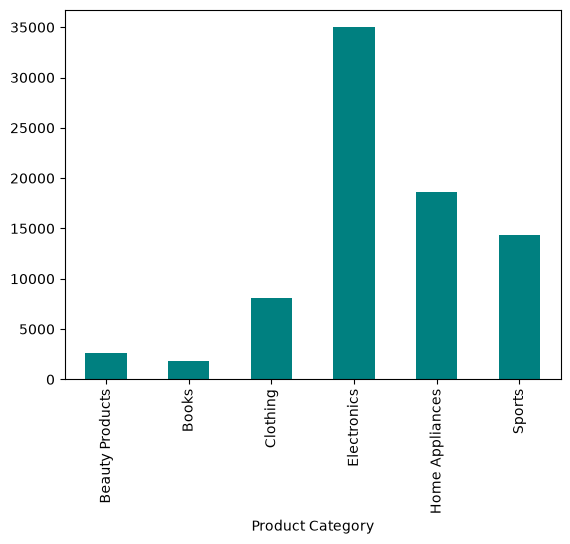

In [24]:
total_sales_by_product.plot(kind='bar',color="teal")


### Sales trend over time

The original example grouped by `Date` while it was text. Parsing dates first gives chronological behavior and date-aware formatting.


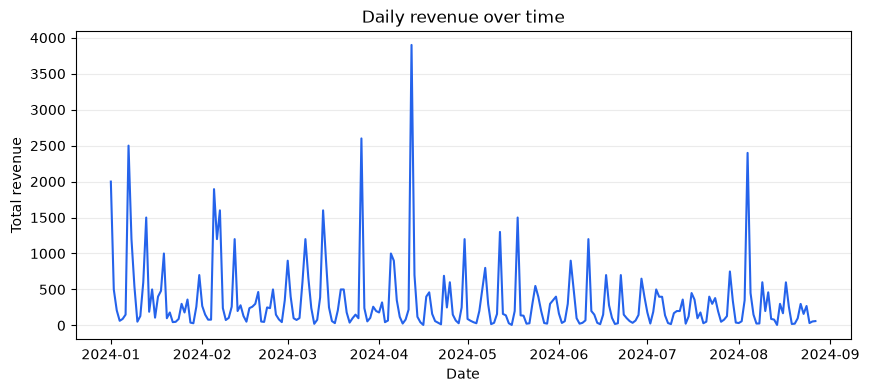

In [25]:
## plot sales trend over time
sales_trend=sales_data_df.groupby('Date')['Total Revenue'].sum().sort_index().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sales_trend['Date'],sales_trend['Total Revenue'], color='#2563EB', linewidth=1.5)
ax.set(title='Daily revenue over time', xlabel='Date', ylabel='Total revenue')
ax.grid(axis='y', alpha=0.25)
plt.show()


Daily data can be noisy. Monthly aggregation answers a different, often clearer question.


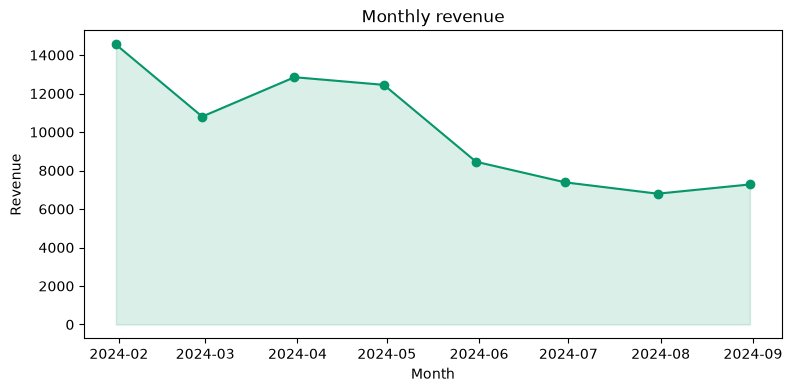

In [26]:
monthly_revenue = (
    sales_data_df.set_index('Date')['Total Revenue']
    .resample('ME')
    .sum()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='#059669')
ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.15, color='#059669')
ax.set(title='Monthly revenue', xlabel='Month', ylabel='Revenue')
plt.show()


## 10. Grouped and stacked bars

A pivot table prepares category-by-region values. Stacking emphasizes the total and its composition; grouped bars emphasize side-by-side comparison.


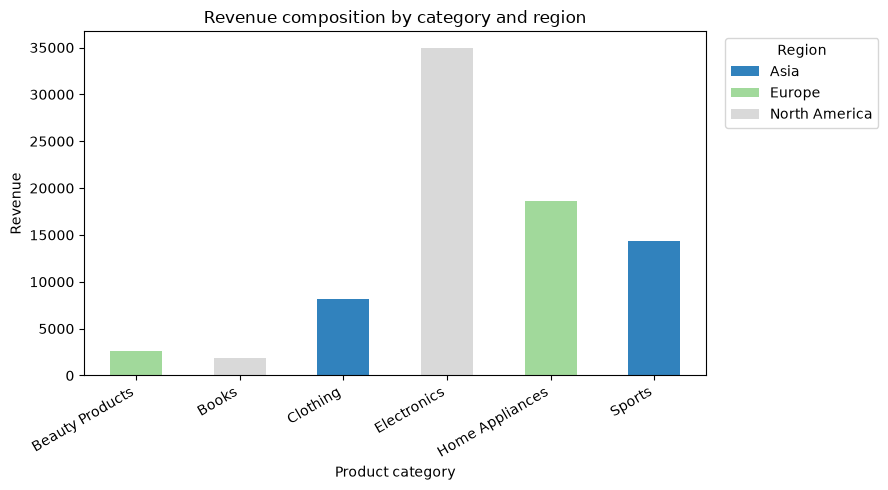

In [21]:
category_region = pd.pivot_table(
    sales_data_df,
    index='Product Category',
    columns='Region',
    values='Total Revenue',
    aggfunc='sum',
    fill_value=0
)

ax = category_region.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='tab20c')
ax.set(title='Revenue composition by category and region', xlabel='Product category', ylabel='Revenue')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 11. Annotations and reference lines


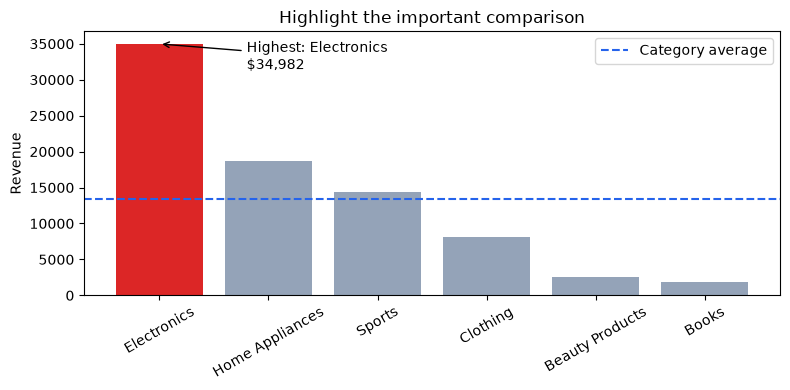

In [22]:
best_category = total_sales_by_product.idxmax()
best_value = total_sales_by_product.max()

fig, ax = plt.subplots(figsize=(8, 4))
ordered = total_sales_by_product.sort_values(ascending=False)
ax.bar(ordered.index, ordered.values, color=['#DC2626'] + ['#94A3B8'] * (len(ordered) - 1))
ax.axhline(ordered.mean(), color='#2563EB', linestyle='--', label='Category average')
ax.annotate(
    f'Highest: {best_category}\n${best_value:,.0f}',
    xy=(0, best_value),
    xytext=(0.8, best_value * 0.9),
    arrowprops={'arrowstyle': '->'}
)
ax.set(title='Highlight the important comparison', ylabel='Revenue')
ax.tick_params(axis='x', rotation=30)
ax.legend()
fig.tight_layout()
plt.show()


## 12. Save a figure

Save before `plt.show()` in scripts because some backends clear the figure afterward. Use a high DPI for reports and `bbox_inches='tight'` to include labels.


In [23]:
demo_output = data_path('sales_data.csv').with_name('matplotlib_demo.png')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot([1, 2, 3], [2, 4, 3], marker='o')
ax.set(title='Saved chart example', xlabel='Step', ylabel='Value')
fig.savefig(demo_output, dpi=150, bbox_inches='tight')
plt.close(fig)

print("saved:", demo_output.exists(), "bytes:", demo_output.stat().st_size)
demo_output.unlink(missing_ok=True)


saved: True bytes: 43787


## 13. Choosing a chart

| Question | Good starting chart |
|---|---|
| How does a value change over ordered time? | line |
| Which category is larger? | sorted bar |
| How are numeric values distributed? | histogram or box plot |
| Are two numeric variables related? | scatter |
| What is the part-to-whole composition? | stacked bar; pie only for a few simple parts |

Color should support meaning. Do not rely on red/green alone; use labels, shapes, or lightness differences too.


## 14. Common mistakes

- plotting before deciding the question;
- missing titles, labels, or units;
- using a line for unordered categories;
- using too many pie slices;
- truncating a bar-chart baseline and exaggerating differences;
- leaving date strings unparsed;
- reusing implicit plotting state and drawing on an old figure;
- forgetting `tight_layout`, `show`, or `close` in repeated workflows;
- using color as the only carrier of meaning.


## Easy revision cheat sheet

```python
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, label='Series')
ax.set(title='Clear title', xlabel='X with unit', ylabel='Y with unit')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

| Need | Method |
|---|---|
| Line | `ax.plot(x, y)` |
| Bar | `ax.bar(categories, values)` |
| Horizontal bar | `ax.barh(categories, values)` |
| Histogram | `ax.hist(values, bins=...)` |
| Scatter | `ax.scatter(x, y)` |
| Reference line | `ax.axhline(...)`, `ax.axvline(...)` |
| Annotation | `ax.annotate(text, xy=...)` |
| Multiple charts | `fig, axes = plt.subplots(r, c)` |
| Save | `fig.savefig(path, dpi=150, bbox_inches='tight')` |
| Release figure | `plt.close(fig)` |

**Memory trick:** Figure is the paper, Axes is the chart, and the chart type should match the question.
